In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow

In [267]:
df_raw = pd.read_csv("Sample-Superstore2019.csv",parse_dates=["Order Date","Ship Date"],)
df=df_raw.copy()

In [268]:
df.shape

(9994, 22)

In [269]:
df = df.iloc[:,2 :]

In [270]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [271]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   str           
 1   Order Date      9994 non-null   datetime64[us]
 2   Ship Date       9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   str           
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Segment         9994 non-null   str           
 7   Country/Region  9994 non-null   str           
 8   City            9994 non-null   str           
 9   State           9994 non-null   str           
 10  Postal Code     9983 non-null   float64       
 11  Region          9994 non-null   str           
 12  Product ID      9994 non-null   str           
 13  Category        9994 non-null   str           
 14  Sub-Category    9994 non-null   str           
 15  Product Name   

In [272]:
df.isna().sum()#postal Code Has 11 null Value

Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [273]:
df[df["Postal Code"].isnull()][["City", "State", "Postal Code"]] # كل القيم الفارغه من Burlington ولايه Vermont 
#pastal code is :05401

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


In [274]:
#هنحول نوع العمود عشان يخزن ال0 اللي في اول الكود
df["Postal Code"]=df["Postal Code"].astype(str)

In [275]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   str           
 1   Order Date      9994 non-null   datetime64[us]
 2   Ship Date       9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   str           
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Segment         9994 non-null   str           
 7   Country/Region  9994 non-null   str           
 8   City            9994 non-null   str           
 9   State           9994 non-null   str           
 10  Postal Code     9983 non-null   str           
 11  Region          9994 non-null   str           
 12  Product ID      9994 non-null   str           
 13  Category        9994 non-null   str           
 14  Sub-Category    9994 non-null   str           
 15  Product Name   

In [276]:
df["Postal Code"]=df["Postal Code"].fillna("05401")

In [277]:
df.memory_usage(deep=True)

Index                132
Order ID          219868
Order Date         79952
Ship Date          79952
Ship Mode         208106
Customer ID       159904
Customer Name     209570
Segment           168273
Country/Region    209874
City              173203
State             164773
Postal Code       149450
Region            128517
Product ID        229862
Category          207901
Sub-Category      151826
Product Name      449496
Sales              79952
Quantity           79952
Discount           79952
Profit             79952
dtype: int64

In [278]:
df["Country/Region"].value_counts() 

Country/Region
United States    9994
Name: count, dtype: int64

In [279]:
df["City"].value_counts()

City
New York City        915
Los Angeles          747
Philadelphia         537
San Francisco        510
Seattle              428
                    ... 
Aberdeen               1
Hagerstown             1
Arlington Heights      1
San Luis Obispo        1
Springdale             1
Name: count, Length: 531, dtype: int64

In [280]:
for col in ["Segment", "Region", "Ship Mode", "Category","State","Sub-Category"]:
    df[col]=df[col].astype("category")

In [281]:
df.info(memory_usage="deep")# Memory usage reduced from 8.6 MB to 5.4 MB ==> 37.2% reduction

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   str           
 1   Order Date      9994 non-null   datetime64[us]
 2   Ship Date       9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   category      
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Segment         9994 non-null   category      
 7   Country/Region  9994 non-null   str           
 8   City            9994 non-null   str           
 9   State           9994 non-null   category      
 10  Postal Code     9994 non-null   str           
 11  Region          9994 non-null   category      
 12  Product ID      9994 non-null   str           
 13  Category        9994 non-null   category      
 14  Sub-Category    9994 non-null   category      
 15  Product Name   

In [282]:
df.duplicated().sum()

np.int64(1)

In [283]:
df.drop_duplicates(inplace=True)

In [284]:
df.describe(include="category")

,Ship Mode,Segment,State,Region,Category,Sub-Category
count,9993,9993,9993,9993,9993,9993
unique,4,3,49,4,3,17
top,Standard Class,Consumer,California,West,Office Supplies,Binders
freq,5967,5191,2001,3203,6026,1523


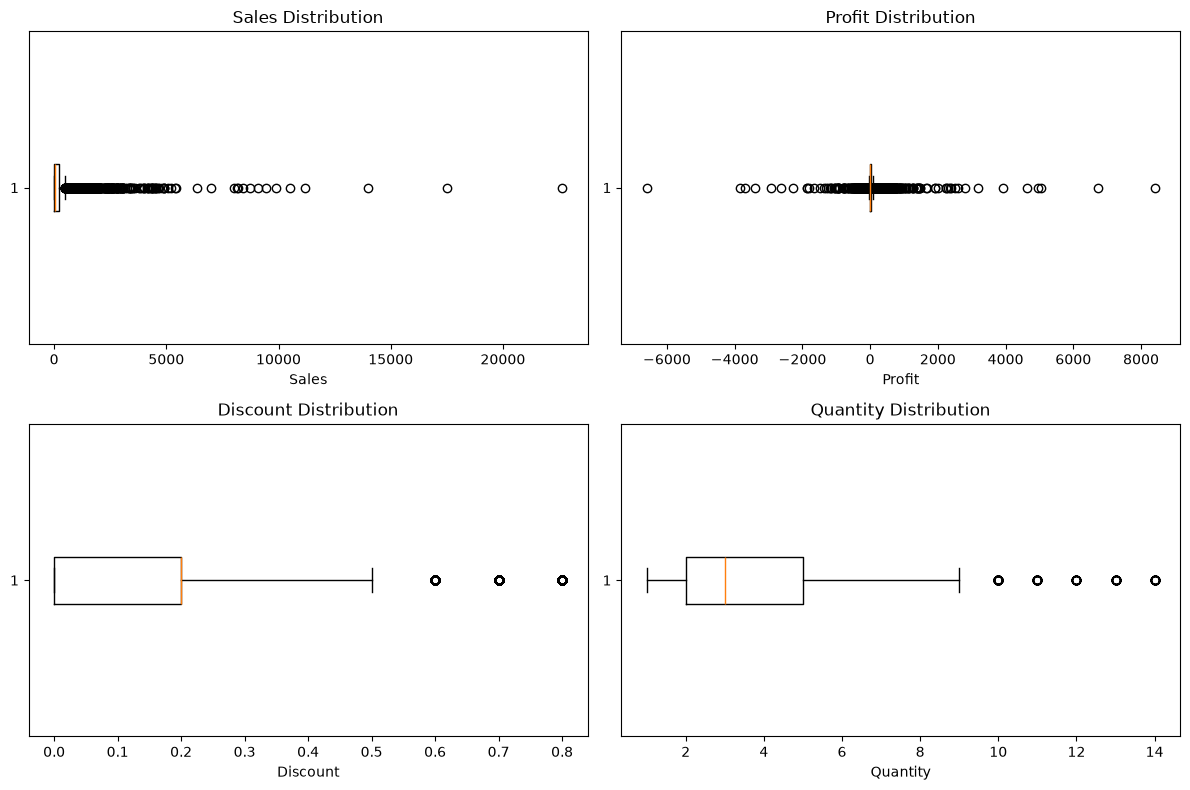

In [285]:

cols = ["Sales", "Profit", "Discount", "Quantity"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), cols):
    ax.boxplot(df[col], orientation="horizontal")
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [286]:
cols = ["Sales", "Profit", "Discount", "Quantity"]

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}")
    print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Number of outliers: {len(outliers)}")


Sales
Outlier bounds: [-271.71, 498.93]
Number of outliers: 1167

Profit
Outlier bounds: [-39.72, 70.81]
Number of outliers: 1881

Discount
Outlier bounds: [-0.30, 0.50]
Number of outliers: 856

Quantity
Outlier bounds: [-2.50, 9.50]
Number of outliers: 170


In [287]:
df.to_parquet("cleaned_data.parquet",engine="pyarrow")